# Matched vs. Mismatched Simple/Hard Pair Discrimination

This notebook reconstructs the **matched-vs-mismatched pair discrimination**
analysis referenced in the paper but not present anywhere else in this
repository's `code/` scripts, for **both models**:

> Across all 279 problems per model, matched Simple/Hard pairs (same
> problem) have much more similar prompt hidden states than unrelated
> problem pairs. This held under multiple pooling strategies (AUC ≈ 0.986
> for Qwen, ≈ 0.980 for Gemma). Textual edit distance explained some, but
> not all, of the difference.

This notebook is fully self-contained — it collects its own activations
(no dependency on any other script in `code/`) and then runs the analysis.

**What this notebook does, per model:**
0. Loads the model directly (Qwen3-8B and Gemma 4 E4B) and collects
   per-layer, per-pooling hidden-state activations for the `simple` and
   `hard` conditions, if they aren't already saved on disk.
1. Loads those activations (files named
   `activations_{position}_{condition}_{mode}.pt`).
2. Builds the **matched** pairs: `Simple_i` vs `Hard_i` (279 pairs, one per
   problem).
3. Builds a random sample of **mismatched** pairs: `Simple_i` vs `Hard_j`
   for `i != j` (~2,000 pairs, sampled without replacement from the
   279x278 possible ordered cross pairs).
4. Computes a distance/similarity score for every pair (cosine distance and
   relative L2, at every layer), and evaluates how well that score
   separates matched from mismatched pairs via **ROC-AUC**.
5. Repeats this across the different token-pooling strategies (`final_token`,
   `mean_token`) to check the result is not an artifact of one pooling
   choice.
6. Computes normalized **textual edit distance** between each Simple/Hard
   problem-text pair and correlates it with the hidden-state distance, to
   see how much of the separation textual similarity alone explains.

It then combines the two models' results into one side-by-side comparison,
matching the AUC 0.986 (Qwen) / 0.980 (Gemma) figures reported in the
paper.

> **Note:** activation collection (Section 3) needs a GPU and downloads
> both models, so it's meant to run in Colab (or any GPU machine). It is
> skipped automatically for any model whose `.pt` files already exist.

## 1. Setup

This notebook is fully self-contained: it does not import anything from
`code/` (in particular it does **not** depend on `code/config.py` or on
`matched_triplets.jsonl` having been built). All path handling, data
loading, and metric code lives directly in this notebook.

### 1.1 Clone or update the GitHub repository (Colab)

Colab's notebook viewer only gives you *this notebook file* — it does not
bring the rest of the repository along with it. The only thing this
notebook actually needs from the repo (besides the activation `.pt` files
you point it at in Section 2) is the raw dataset:
`MATH-Perturb/math_perturb/math_perturb_simple.jsonl` and
`math_perturb_hard.jsonl` — both already tracked in git. This cell clones
the repo into `/content/...` the first time, or does a fast-forward
`git pull` if it's already there. If you're running this locally and
already inside a checkout of the repo, this cell is a no-op.

This step loads the code and data the notebook needs (like downloading a folder before opening its files) and imports the math libraries (`numpy`, `torch`, etc.) that do the calculations.


In [1]:
import subprocess
from pathlib import Path

REPOSITORY_NAME = (
    "Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations"
)
REPOSITORY_URL = (
    "https://github.com/yohaankharas906/"
    "Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations.git"
)

def _has_dataset(root: Path) -> bool:
    data_dir = root / "MATH-Perturb" / "math_perturb"
    return (data_dir / "math_perturb_simple.jsonl").is_file() and (data_dir / "math_perturb_hard.jsonl").is_file()

current_folder = Path.cwd()

if _has_dataset(current_folder):
    REPO_ROOT = current_folder
else:
    REPO_ROOT = Path("/content") / REPOSITORY_NAME

if (REPO_ROOT / ".git").is_dir():
    print(f"Repository already present at {REPO_ROOT}; pulling latest changes...")
    subprocess.check_call(["git", "-C", str(REPO_ROOT), "pull", "--ff-only"])
elif REPO_ROOT.exists():
    raise FileNotFoundError(
        f"{REPO_ROOT} exists but is not a Git repository. "
        "Rename or remove that folder, then run this cell again."
    )
else:
    print("Cloning the project repository now...")
    subprocess.check_call(
        ["git", "clone", "--depth", "1", REPOSITORY_URL, str(REPO_ROOT)]
    )

assert _has_dataset(REPO_ROOT), (
    f"{REPO_ROOT} does not contain the MATH-Perturb simple/hard data files."
)
print("Repo root:", REPO_ROOT)

Cloning the project repository now...
Repo root: /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations


### 1.2 Imports

In [2]:
import json

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

ROOT = REPO_ROOT
SIMPLE_PATH = ROOT / "MATH-Perturb" / "math_perturb" / "math_perturb_simple.jsonl"
HARD_PATH = ROOT / "MATH-Perturb" / "math_perturb" / "math_perturb_hard.jsonl"

def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

print(f"Repo root: {ROOT}")
print(f"Simple data: {SIMPLE_PATH}")
print(f"Hard data:   {HARD_PATH}")

Repo root: /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations
Simple data: /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/math_perturb/math_perturb_simple.jsonl
Hard data:   /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/math_perturb/math_perturb_hard.jsonl


## 2. Configuration

- `MODELS`: one entry per model — its HF Hub id (used only if activations
  need to be collected) and where its activation `.pt` files live.
  Add/remove entries here to run additional models.
- `N_MISMATCHED_PAIRS`: how many cross-problem `Simple_i`/`Hard_j` pairs to
  sample (default 2,000, matching the paper).
- `POSITIONS`: which pooling strategies to compute/evaluate.
- `MODE`: kept as `"non_thinking"` for filename compatibility with
  `code/03_collect_activations.py`'s naming convention.
- `SEED`: random seed for reproducible mismatched-pair sampling.

These are the settings for the whole notebook: which two AI models to study, how many mismatched pairs to compare (2,000, matching the paper), and which ways of summarizing a prompt into one vector ("pooling") to try. Change these numbers and rerun everything below without touching any other code.


In [3]:
MODELS = [
    {
        "key": "qwen3", "label": "Qwen3-8B", "hf_model_id": "Qwen/Qwen3-8B",
        "activations_dir": ROOT / "results" / "activations" / "qwen3",
    },
    {
        "key": "gemma4", "label": "Gemma 4 E4B", "hf_model_id": "google/gemma-4-E4B-it",
        "activations_dir": ROOT / "results" / "activations" / "gemma4",
    },
]

N_MISMATCHED_PAIRS = 2000
POSITIONS = ["final_token", "mean_token"]
MODE = "non_thinking"
SEED = 0

## 3. Collect activations (run once per model; needs a GPU)

Self-contained activation collection — no dependency on
`code/03_collect_activations.py`. For each model in `MODELS`, and for
every problem in the Simple/Hard dataset loaded in Section 1, this:

1. Loads the model (`AutoModelForCausalLM`, falling back to
   `AutoModelForMultimodalLM` for models like Gemma 4 that register a
   multimodal wrapper class even for text-only checkpoints).
2. Formats the problem as a chat prompt (disabling any visible
   'thinking' mode, matching the other tutorials in this repo).
3. Runs a forward pass with `output_hidden_states=True` and pools every
   layer's hidden states two ways: `final_token` (the last prompt token)
   and `mean_token` (mean over all prompt tokens).
4. Saves one `.pt` file per `(position, condition)` pair into the model's
   `activations_dir`, in exactly the format Section 4 expects:
   `activations_{position}_{condition}_{mode}.pt` containing
   `{"activations": (N, num_layers, hidden_dim), "problem_ids": [...]}`.

Collection is **skipped automatically** for any model whose activation
files already exist in its `activations_dir` — safe to re-run this cell.
Set `FORCE_RECOLLECT = True` below to overwrite existing files instead.

> Loading two ~8B-parameter models sequentially needs a GPU with enough
> headroom (an A100 is plenty); the model is deleted and its GPU memory
> freed after each model finishes.

As a language model reads a math problem one word-piece at a time, each layer builds up a list of numbers describing what it has "understood" so far, called a **hidden state**. Think of it like a student's scratch notes after reading a question: you can't see the notes directly, but you can compare two students' notes to see if they were reading similar problems. This step runs each model on all 279 Simple and 279 Hard problems and saves a compressed version of those notes for comparison later.


In [ ]:
FORCE_RECOLLECT = False
SYSTEM_PROMPT = (
    "Solve the mathematics problem carefully. Show your reasoning and "
    "put the final answer inside \\boxed{}."
)
MAX_INPUT_TOKENS = 1024

In [5]:
import gc

import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU was found. In Colab: Runtime -> Change runtime type -> GPU."
    )
DEVICE = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))

GPU: NVIDIA A100-SXM4-80GB


In [6]:
def model_needs_collection(activations_dir: Path) -> bool:
    if FORCE_RECOLLECT:
        return True
    for pos in POSITIONS:
        for cond in ("simple", "hard"):
            if not (activations_dir / f"activations_{pos}_{cond}_{MODE}.pt").exists():
                return True
    return False


def ensure_chat_template(tokenizer, hf_model_id: str):
    """Some repos ship the chat template as a separate `chat_template.jinja`
    file rather than inside tokenizer_config.json; older/newer transformers
    versions don't always pick that up automatically via AutoTokenizer."""
    if getattr(tokenizer, "chat_template", None):
        return tokenizer
    from huggingface_hub import hf_hub_download
    for filename in ("chat_template.jinja", "chat_template.json"):
        try:
            path = hf_hub_download(repo_id=hf_model_id, filename=filename)
        except Exception:
            continue
        text = Path(path).read_text(encoding="utf-8")
        if filename.endswith(".json"):
            text = json.loads(text)["chat_template"]
        tokenizer.chat_template = text
        print(f"[{hf_model_id}] loaded chat template from {filename}")
        return tokenizer
    return None


def get_chat_applier(hf_model_id: str, tokenizer):
    """Find something with a usable apply_chat_template: the tokenizer
    itself, or (for multimodal checkpoints like Gemma 4, whose chat template
    lives with the Processor class rather than the tokenizer) an
    AutoProcessor."""
    patched = ensure_chat_template(tokenizer, hf_model_id)
    if patched is not None:
        return patched
    try:
        from transformers import AutoProcessor
        processor = AutoProcessor.from_pretrained(hf_model_id)
        if getattr(processor, "chat_template", None):
            return processor
    except Exception as exc:
        print(f"[{hf_model_id}] AutoProcessor fallback failed: {exc}")
    raise ValueError(
        f"{hf_model_id} has no usable chat template on its tokenizer, no "
        "chat_template.jinja/.json in its repo, and AutoProcessor didn't "
        "provide one either. Pass a template manually."
    )


def load_causal_lm(hf_model_id: str):
    tokenizer = AutoTokenizer.from_pretrained(hf_model_id)
    tokenizer.truncation_side = "left"
    chat_applier = get_chat_applier(hf_model_id, tokenizer)
    try:
        model = AutoModelForCausalLM.from_pretrained(
            hf_model_id, dtype=torch.bfloat16, low_cpu_mem_usage=True,
        ).to(DEVICE)
    except ValueError:
        # Some checkpoints (e.g. Gemma 4) register a multimodal wrapper class
        # even when used text-only.
        from transformers import AutoModelForMultimodalLM
        model = AutoModelForMultimodalLM.from_pretrained(
            hf_model_id, dtype=torch.bfloat16, low_cpu_mem_usage=True,
        ).to(DEVICE)
    model.eval()
    return model, tokenizer, chat_applier


def format_prompt(chat_applier, problem: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": problem},
    ]
    try:
        return chat_applier.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
        )
    except TypeError:
        # Some processors' templates don't accept enable_thinking.
        return chat_applier.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )


def pool_prompt_hidden_states(hidden_states, n_valid: int) -> dict[str, torch.Tensor]:
    """hidden_states: tuple of (1, seq_len, hidden_dim) tensors, one per site
    (embeddings + each transformer layer). Returns {position: (num_layers, hidden_dim)}.
    """
    final_token = torch.stack([h[0, n_valid - 1].float().cpu() for h in hidden_states])
    mean_token = torch.stack([h[0, :n_valid].float().mean(dim=0).cpu() for h in hidden_states])
    return {"final_token": final_token, "mean_token": mean_token}


def collect_activations_for_model(m: dict, simple_rows: list[dict], hard_rows: list[dict]):
    activations_dir = m["activations_dir"]
    activations_dir.mkdir(parents=True, exist_ok=True)

    if not model_needs_collection(activations_dir):
        print(f"[{m['label']}] activation files already present in {activations_dir}, skipping collection.")
        return

    print(f"[{m['label']}] loading {m['hf_model_id']}...")
    model, tokenizer, chat_applier = load_causal_lm(m["hf_model_id"])

    conditions = {"simple": simple_rows, "hard": hard_rows}
    problem_ids = [row["problem_id"] for row in simple_rows]
    pooled = {pos: {cond: [] for cond in conditions} for pos in POSITIONS}

    for cond, rows in conditions.items():
        for row in tqdm(rows, desc=f"[{m['label']}] {cond}"):
            prompt_text = format_prompt(chat_applier, row["problem"])
            inputs = tokenizer(
                prompt_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT_TOKENS,
            ).to(DEVICE)
            n_valid = inputs["input_ids"].shape[1]
            with torch.inference_mode():
                out = model(**inputs, output_hidden_states=True)
            site_pooled = pool_prompt_hidden_states(out.hidden_states, n_valid)
            for pos in POSITIONS:
                pooled[pos][cond].append(site_pooled[pos])
            del out

    for pos in POSITIONS:
        for cond in conditions:
            tensor = torch.stack(pooled[pos][cond])  # (N, num_sites, hidden_dim)
            save_path = activations_dir / f"activations_{pos}_{cond}_{MODE}.pt"
            torch.save({
                "activations": tensor,
                "problem_ids": problem_ids,
                "position": pos,
                "condition": cond,
                "model": m["hf_model_id"],
            }, save_path)
            print(f"[{m['label']}] saved {save_path} shape={tuple(tensor.shape)}")

    del model, tokenizer, chat_applier
    gc.collect()
    torch.cuda.empty_cache()


simple_rows = load_jsonl(SIMPLE_PATH)
hard_rows = load_jsonl(HARD_PATH)
assert [r["problem_id"] for r in simple_rows] == [r["problem_id"] for r in hard_rows], \
    "Simple/Hard problem_id ordering mismatch"

for m in MODELS:
    collect_activations_for_model(m, simple_rows, hard_rows)

[Qwen3-8B] loading Qwen/Qwen3-8B...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

[Gemma 4 E4B] simple:   0%|          | 0/279 [00:00<?, ?it/s]

[Gemma 4 E4B] hard:   0%|          | 0/279 [00:00<?, ?it/s]

[Gemma 4 E4B] saved /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/results/activations/gemma4/activations_final_token_simple_non_thinking.pt shape=(279, 43, 2560)
[Gemma 4 E4B] saved /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/results/activations/gemma4/activations_final_token_hard_non_thinking.pt shape=(279, 43, 2560)
[Gemma 4 E4B] saved /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/results/activations/gemma4/activations_mean_token_simple_non_thinking.pt shape=(279, 43, 2560)
[Gemma 4 E4B] saved /content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/results/activations/gemma4/activations_mean_token_hard_non_thinking.pt shape=(279, 43, 2560)


## 4. Load activations

Loads whichever `(position, condition)` activation files are available
for each model. Each file holds a tensor of shape
`(N_problems, num_layers, hidden_dim)` plus the aligned `problem_ids` list.

This step loads the files saved in Section 3 and checks that the Simple and Hard problems line up correctly before any comparisons are made.


In [7]:
def load_activation_file(activations_dir: Path, position: str, condition: str, mode: str = MODE):
    path = activations_dir / f"activations_{position}_{condition}_{mode}.pt"
    if not path.exists():
        return None
    return torch.load(path, map_location="cpu")

def load_model_activations(activations_dir: Path, label: str):
    available = {}
    for pos in POSITIONS:
        simple_payload = load_activation_file(activations_dir, pos, "simple")
        hard_payload = load_activation_file(activations_dir, pos, "hard")
        if simple_payload is None or hard_payload is None:
            print(f"[{label}] [skip] no activations found for position={pos!r} in {activations_dir}")
            continue
        assert simple_payload["problem_ids"] == hard_payload["problem_ids"], \
            f"[{label}] problem_id ordering mismatch for position={pos!r}"
        available[pos] = {"simple": simple_payload, "hard": hard_payload}
        n, n_layers, hidden_dim = simple_payload["activations"].shape
        print(f"[{label}] position={pos!r}: N={n} problems, num_layers={n_layers}, hidden_dim={hidden_dim}")
    return available

for m in MODELS:
    m["available"] = load_model_activations(m["activations_dir"], m["label"])

MODELS = [m for m in MODELS if m["available"]]
if not MODELS:
    raise RuntimeError(
        "No activation files found for any configured model. Run Section 3 "
        "(Collect activations) first."
    )
for m in MODELS:
    m["problem_ids"] = m["available"][next(iter(m["available"]))]["simple"]["problem_ids"]
    m["N"] = len(m["problem_ids"])
    print(f"{m['label']}: {m['N']} problems")

[Qwen3-8B] position='final_token': N=279 problems, num_layers=37, hidden_dim=4096
[Qwen3-8B] position='mean_token': N=279 problems, num_layers=37, hidden_dim=4096
[Gemma 4 E4B] position='final_token': N=279 problems, num_layers=43, hidden_dim=2560
[Gemma 4 E4B] position='mean_token': N=279 problems, num_layers=43, hidden_dim=2560
Qwen3-8B: 279 problems
Gemma 4 E4B: 279 problems


## 5. Build matched and mismatched pairs

- **Matched**: `(i, i)` for every problem `i` — `N` pairs.
- **Mismatched**: `(i, j)` with `i != j`, sampled uniformly at random
  without replacement from all `N * (N - 1)` ordered cross pairs, capped
  at `N_MISMATCHED_PAIRS`. Pairs are sampled independently per model (each
  model uses its own RNG stream seeded from `SEED`).

To test whether Simple and Hard versions of the *same* problem look similar to the model, we need something to compare against: Simple and Hard versions of *different* problems. A **matched pair** is Simple problem 5 with Hard problem 5. A **mismatched pair** is Simple problem 5 with Hard problem 91, an unrelated problem. We build all 279 matched pairs, and randomly pick about 2,000 mismatched pairs out of the roughly 77,500 possible ones.


In [8]:
def sample_mismatched_pairs(n: int, n_pairs: int, rng: np.random.Generator):
    n_pairs = min(n_pairs, n * (n - 1))
    pairs = set()
    while len(pairs) < n_pairs:
        i, j = rng.integers(0, n, size=2)
        if i != j:
            pairs.add((int(i), int(j)))
    return sorted(pairs)

for m in MODELS:
    rng = np.random.default_rng(SEED)
    m["matched_pairs"] = [(i, i) for i in range(m["N"])]
    m["mismatched_pairs"] = sample_mismatched_pairs(m["N"], N_MISMATCHED_PAIRS, rng)
    print(f"{m['label']}: matched={len(m['matched_pairs'])}, mismatched={len(m['mismatched_pairs'])}")

Qwen3-8B: matched=279, mismatched=2000
Gemma 4 E4B: matched=279, mismatched=2000


## 6. Pairwise distance / similarity metrics

For a given pooling position and layer, computes cosine distance and
relative L2 distance between `Simple_i` and `Hard_j` for every `(i, j)`
pair in a list. Shared across models.

We need a number for "how different are two sets of hidden-state notes?" We use two: **cosine distance** (do the two lists of numbers point in a similar direction?) and **relative L2** (how far apart are the numbers, as a fraction of their size?). Neither is the "correct" one; using both checks that our conclusions don't depend on which we pick.


In [9]:
def cosine_distance(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    a = a / a.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    b = b / b.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    return 1.0 - (a * b).sum(dim=-1)

def relative_l2(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    diff = (a - b).norm(dim=-1)
    denom = a.norm(dim=-1).clamp_min(1e-8)
    return diff / denom

def pair_distances(simple_acts: torch.Tensor, hard_acts: torch.Tensor,
                    pairs: list[tuple[int, int]], layer: int):
    """simple_acts, hard_acts: (N, num_layers, hidden_dim)."""
    idx_i = torch.tensor([p[0] for p in pairs])
    idx_j = torch.tensor([p[1] for p in pairs])
    a = simple_acts[idx_i, layer, :]
    b = hard_acts[idx_j, layer, :]
    return cosine_distance(a, b), relative_l2(a, b)

## 7. AUC: how well does hidden-state distance separate matched from mismatched pairs?

For each model, each pooling position, and each layer, treat `matched=1` /
`mismatched=0` as the label and the *negative* distance as the score
(smaller distance -> more likely matched), then compute ROC-AUC.

Imagine sorting every pair, matched and mismatched, from most similar hidden states to least similar, then asking: using only that order, how well could you guess which pairs were matched? That score is the **AUC (Area Under the Curve)**: 1.0 means perfect guessing, 0.5 means no better than a coin flip. We compute this for every layer and pooling method, since we don't know in advance which one will show the effect best.


In [10]:
def compute_auc_table(m: dict) -> pd.DataFrame:
    records = []
    labels = np.array([1] * len(m["matched_pairs"]) + [0] * len(m["mismatched_pairs"]))
    for pos, payload in m["available"].items():
        simple_acts = payload["simple"]["activations"]
        hard_acts = payload["hard"]["activations"]
        n_layers = simple_acts.shape[1]
        for layer in range(n_layers):
            cos_m, l2_m = pair_distances(simple_acts, hard_acts, m["matched_pairs"], layer)
            cos_u, l2_u = pair_distances(simple_acts, hard_acts, m["mismatched_pairs"], layer)
            cos_all = torch.cat([cos_m, cos_u]).numpy()
            l2_all = torch.cat([l2_m, l2_u]).numpy()
            records.append({
                "model": m["label"], "position": pos, "layer": layer, "metric": "cosine_distance",
                "auc": roc_auc_score(labels, -cos_all),
                "matched_mean": cos_m.mean().item(), "matched_median": cos_m.median().item(),
                "mismatched_mean": cos_u.mean().item(), "mismatched_median": cos_u.median().item(),
            })
            records.append({
                "model": m["label"], "position": pos, "layer": layer, "metric": "relative_l2",
                "auc": roc_auc_score(labels, -l2_all),
                "matched_mean": l2_m.mean().item(), "matched_median": l2_m.median().item(),
                "mismatched_mean": l2_u.mean().item(), "mismatched_median": l2_u.median().item(),
            })
    return pd.DataFrame(records)

for m in MODELS:
    m["auc_df"] = compute_auc_table(m)

auc_df = pd.concat([m["auc_df"] for m in MODELS], ignore_index=True)
auc_df.head()

,model,position,layer,metric,auc,matched_mean,matched_median,mismatched_mean,mismatched_median
0,Qwen3-8B,final_token,0,cosine_distance,0.500000,-9.536743e-07,-9.536743e-07,-9.536743e-07,-9.536743e-07
1,Qwen3-8B,final_token,0,relative_l2,0.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Qwen3-8B,final_token,1,cosine_distance,0.981315,5.059535e-04,2.337098e-04,5.311334e-03,4.167140e-03
3,Qwen3-8B,final_token,1,relative_l2,0.981138,2.635697e-02,2.184937e-02,9.870013e-02,9.237777e-02
4,Qwen3-8B,final_token,2,cosine_distance,0.982596,1.394096e-03,8.878708e-04,9.191788e-03,7.629573e-03


### Best layer per model/position/metric, and overall best AUC per model

These are the numbers to compare against the paper's reported AUCs
(~0.986 Qwen / ~0.980 Gemma) — the best-separating layer under the
best-separating pooling/metric combination, per model.

In [11]:
best_per_group = (
    auc_df.sort_values("auc", ascending=False)
    .groupby(["model", "position", "metric"])
    .head(1)
    .sort_values(["model", "auc"], ascending=[True, False])
    .reset_index(drop=True)
)
best_per_group

,model,position,layer,metric,auc,matched_mean,matched_median,mismatched_mean,mismatched_median
0,Gemma 4 E4B,mean_token,15,cosine_distance,0.999341,0.000931,0.000522,0.013574,0.013024
1,Gemma 4 E4B,mean_token,15,relative_l2,0.998950,0.038386,0.032743,0.165092,0.163918
2,Gemma 4 E4B,final_token,28,cosine_distance,0.996030,0.012086,0.007355,0.085747,0.084097
3,Gemma 4 E4B,final_token,28,relative_l2,0.995928,0.137791,0.121148,0.410691,0.410527
4,Qwen3-8B,mean_token,5,cosine_distance,0.996391,0.001022,0.000437,0.016582,0.014484
5,Qwen3-8B,mean_token,5,relative_l2,0.996099,0.038026,0.029772,0.182688,0.175885
6,Qwen3-8B,final_token,13,cosine_distance,0.995381,0.002381,0.001716,0.020293,0.018672
7,Qwen3-8B,final_token,13,relative_l2,0.995174,0.062141,0.058773,0.198228,0.194052


In [12]:
best_per_model = (
    auc_df.sort_values("auc", ascending=False)
    .groupby("model")
    .head(1)[["model", "position", "metric", "layer", "auc"]]
    .reset_index(drop=True)
)
print("Best AUC per model (compare against paper: Qwen ~0.986, Gemma ~0.980):")
best_per_model

Best AUC per model (compare against paper: Qwen ~0.986, Gemma ~0.980):


,model,position,metric,layer,auc
0,Gemma 4 E4B,mean_token,cosine_distance,15,0.999341
1,Qwen3-8B,mean_token,cosine_distance,5,0.996391


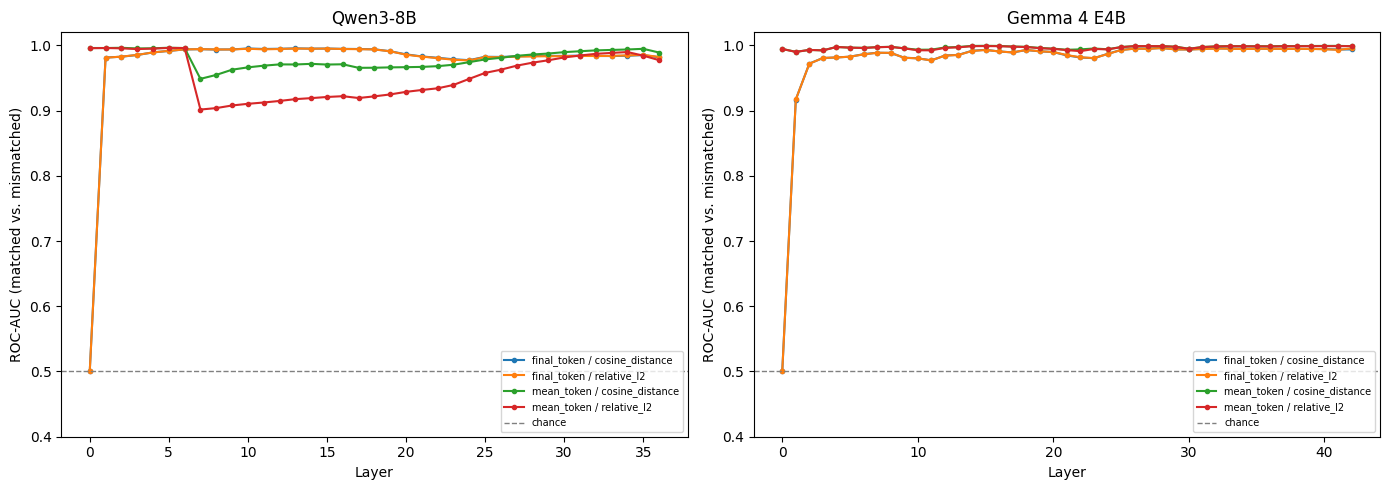

In [13]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 5), squeeze=False)
axes = axes[0]
for ax, m in zip(axes, MODELS):
    df = m["auc_df"]
    for (pos, metric), group in df.groupby(["position", "metric"]):
        ax.plot(group["layer"], group["auc"], marker="o", markersize=3,
                label=f"{pos} / {metric}")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance")
    ax.set_xlabel("Layer")
    ax.set_ylabel("ROC-AUC (matched vs. mismatched)")
    ax.set_title(m["label"])
    ax.legend(fontsize=7, loc="lower right")
    ax.set_ylim(0.4, 1.02)
plt.tight_layout()
plt.show()

## 8. Matched vs. mismatched distance distributions

Histogram of matched vs. mismatched distances at each model's
best-performing layer/position/metric combination, to sanity-check the
AUC number visually and to report mean/median for both groups (as in the
paper).

The AUC number from Section 7 is a single score. This step draws the picture behind it: two overlapping histograms, one for matched pairs' distances and one for mismatched pairs' distances. The less the histograms overlap, the higher the AUC.


In [14]:
for m in MODELS:
    top = best_per_model[best_per_model["model"] == m["label"]].iloc[0]
    top_pos, top_layer, top_metric = top["position"], int(top["layer"]), top["metric"]
    m["top"] = {"position": top_pos, "layer": top_layer, "metric": top_metric, "auc": top["auc"]}
    print(f"[{m['label']}] Best combination: position={top_pos!r}, layer={top_layer}, "
          f"metric={top_metric!r}, AUC={top['auc']:.4f}")

    simple_acts = m["available"][top_pos]["simple"]["activations"]
    hard_acts = m["available"][top_pos]["hard"]["activations"]

    cos_m, l2_m = pair_distances(simple_acts, hard_acts, m["matched_pairs"], top_layer)
    cos_u, l2_u = pair_distances(simple_acts, hard_acts, m["mismatched_pairs"], top_layer)
    matched_d = (cos_m if top_metric == "cosine_distance" else l2_m).numpy()
    mismatched_d = (cos_u if top_metric == "cosine_distance" else l2_u).numpy()
    m["top"]["matched_d"] = matched_d
    m["top"]["mismatched_d"] = mismatched_d

    print(f"  Matched:    n={len(matched_d)}, mean={matched_d.mean():.4f}, median={np.median(matched_d):.4f}")
    print(f"  Mismatched: n={len(mismatched_d)}, mean={mismatched_d.mean():.4f}, median={np.median(mismatched_d):.4f}")

[Qwen3-8B] Best combination: position='mean_token', layer=5, metric='cosine_distance', AUC=0.9964
  Matched:    n=279, mean=0.0010, median=0.0004
  Mismatched: n=2000, mean=0.0166, median=0.0145
[Gemma 4 E4B] Best combination: position='mean_token', layer=15, metric='cosine_distance', AUC=0.9993
  Matched:    n=279, mean=0.0009, median=0.0005
  Mismatched: n=2000, mean=0.0136, median=0.0130


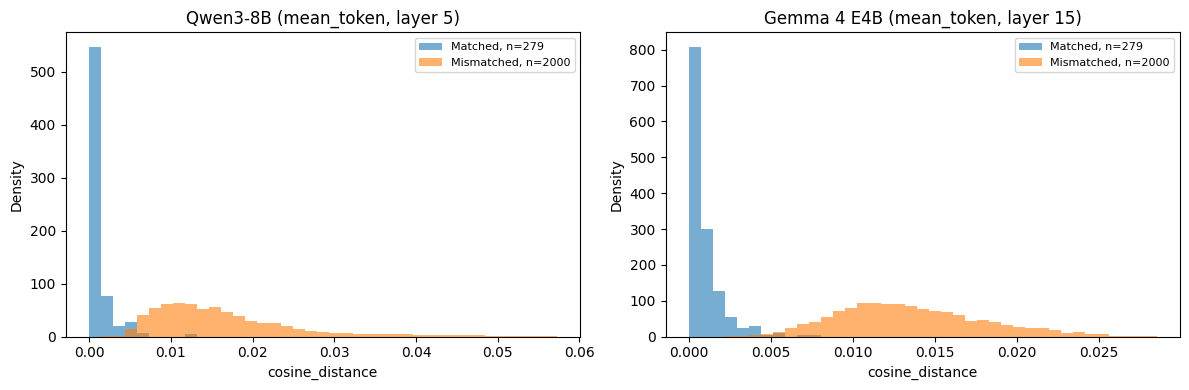

In [15]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
axes = axes[0]
for ax, m in zip(axes, MODELS):
    matched_d, mismatched_d = m["top"]["matched_d"], m["top"]["mismatched_d"]
    bins = np.linspace(0, max(matched_d.max(), mismatched_d.max()), 40)
    ax.hist(matched_d, bins=bins, alpha=0.6, density=True, label=f"Matched, n={len(matched_d)}")
    ax.hist(mismatched_d, bins=bins, alpha=0.6, density=True, label=f"Mismatched, n={len(mismatched_d)}")
    ax.set_xlabel(m["top"]["metric"])
    ax.set_ylabel("Density")
    ax.set_title(f"{m['label']} ({m['top']['position']}, layer {m['top']['layer']})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. How much does textual edit distance explain?

Compute normalized Levenshtein edit distance between each pair's
problem *text* (Simple_i text vs. Hard_j text), and correlate it with the
hidden-state distance for the same pairs. If hidden-state distance tracked
textual distance perfectly, the correlation would be ~1; the paper reports
it explains "some, but not all" of the separation. The Simple/Hard text
pairs are shared across models (same underlying problems), so this only
needs to be computed once per model's own `problem_ids` ordering.

Matched Simple/Hard problems share almost all their wording, since only a few numbers or details change, while mismatched pairs are two completely different problems. So it's no surprise matched pairs' *text* is more similar too. This step asks: how similar is the text alone (measured by **edit distance**, the number of single-character edits to turn one piece of text into the other), and does that already explain most of the hidden-state effect from Section 7? This is where the important catch discussed in Section 11 shows up.


In [16]:
def levenshtein(a: str, b: str) -> int:
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i] + [0] * len(b)
        for j, cb in enumerate(b, 1):
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb))
        prev = curr
    return prev[-1]

def normalized_edit_distance(a: str, b: str) -> float:
    d = levenshtein(a, b)
    return d / max(len(a), len(b), 1)

simple_by_id = {row["problem_id"]: row["problem"] for row in load_jsonl(SIMPLE_PATH)}
hard_by_id = {row["problem_id"]: row["problem"] for row in load_jsonl(HARD_PATH)}

for m in MODELS:
    simple_text = [simple_by_id[pid] for pid in m["problem_ids"]]
    hard_text = [hard_by_id[pid] for pid in m["problem_ids"]]
    all_pairs = m["matched_pairs"] + m["mismatched_pairs"]
    labels = np.array([1] * len(m["matched_pairs"]) + [0] * len(m["mismatched_pairs"]))

    edit_dist = np.array([
        normalized_edit_distance(simple_text[i], hard_text[j]) for i, j in all_pairs
    ])

    top = m["top"]
    simple_acts = m["available"][top["position"]]["simple"]["activations"]
    hard_acts = m["available"][top["position"]]["hard"]["activations"]
    cos_all, l2_all = pair_distances(simple_acts, hard_acts, all_pairs, top["layer"])
    hidden_dist = (cos_all if top["metric"] == "cosine_distance" else l2_all).numpy()

    corr = np.corrcoef(edit_dist, hidden_dist)[0, 1]
    auc_edit_only = roc_auc_score(labels, -edit_dist)

    m["top"]["edit_dist"] = edit_dist
    m["top"]["hidden_dist"] = hidden_dist
    m["top"]["labels"] = labels
    m["top"]["corr"] = corr
    m["top"]["auc_edit_only"] = auc_edit_only

    print(f"[{m['label']}] Pearson correlation(edit distance, hidden-state {top['metric']}) = {corr:.3f}")
    print(f"[{m['label']}] AUC using textual edit distance alone: {auc_edit_only:.4f}")
    print(f"[{m['label']}] AUC using hidden-state {top['metric']} alone: {top['auc']:.4f}")

[Qwen3-8B] Pearson correlation(edit distance, hidden-state cosine_distance) = 0.604
[Qwen3-8B] AUC using textual edit distance alone: 0.9968
[Qwen3-8B] AUC using hidden-state cosine_distance alone: 0.9964
[Gemma 4 E4B] Pearson correlation(edit distance, hidden-state cosine_distance) = 0.755
[Gemma 4 E4B] AUC using textual edit distance alone: 0.9968
[Gemma 4 E4B] AUC using hidden-state cosine_distance alone: 0.9993


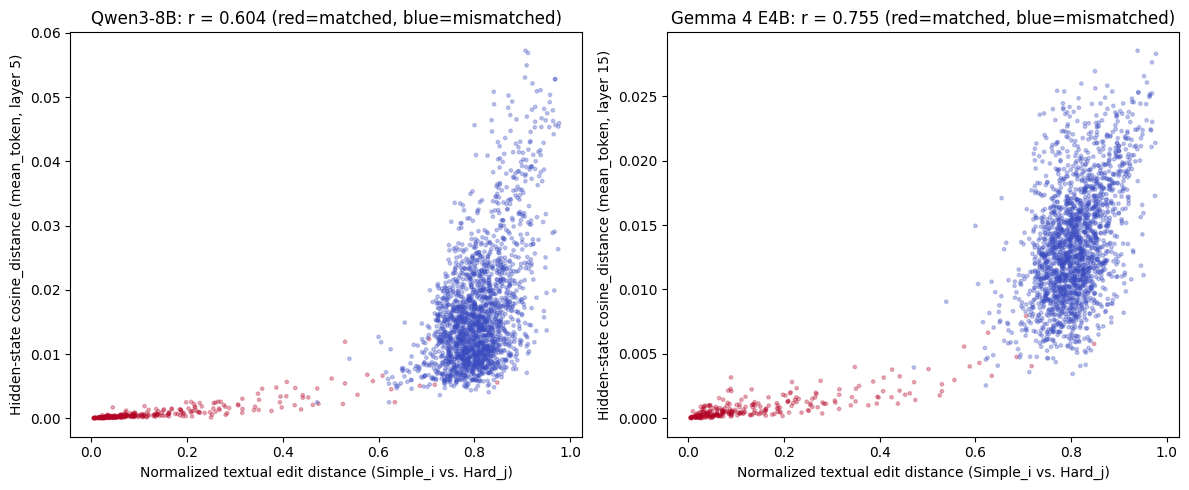

In [17]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 5), squeeze=False)
axes = axes[0]
for ax, m in zip(axes, MODELS):
    top = m["top"]
    ax.scatter(top["edit_dist"], top["hidden_dist"], s=6, alpha=0.3, c=top["labels"], cmap="coolwarm")
    ax.set_xlabel("Normalized textual edit distance (Simple_i vs. Hard_j)")
    ax.set_ylabel(f"Hidden-state {top['metric']} ({top['position']}, layer {top['layer']})")
    ax.set_title(f"{m['label']}: r = {top['corr']:.3f} (red=matched, blue=mismatched)")
plt.tight_layout()
plt.show()

## 10. Summary: both models side by side

Reproduces the headline numbers for each model — best AUC per pooling
strategy (to show the result is robust across pooling choices), plus the
edit-distance comparison — as a single table for comparing against the
paper's reported figures (AUC ~0.986 Qwen / ~0.980 Gemma).

A recap table combining the best AUC for each model and pooling method, so you can compare both models side by side against the paper's reported numbers (Qwen ~0.986, Gemma ~0.980).


In [18]:
summary_rows = []
for m in MODELS:
    per_position = (
        m["auc_df"].sort_values("auc", ascending=False)
        .groupby("position")
        .head(1)[["position", "metric", "layer", "auc"]]
    )
    for _, row in per_position.iterrows():
        summary_rows.append({
            "model": m["label"],
            "position": row["position"],
            "metric": row["metric"],
            "layer": row["layer"],
            "auc": row["auc"],
            "n_matched": len(m["matched_pairs"]),
            "n_mismatched": len(m["mismatched_pairs"]),
        })

summary = pd.DataFrame(summary_rows).sort_values(["model", "auc"], ascending=[True, False]).reset_index(drop=True)
summary

,model,position,metric,layer,auc,n_matched,n_mismatched
0,Gemma 4 E4B,mean_token,cosine_distance,15,0.999341,279,2000
1,Gemma 4 E4B,final_token,cosine_distance,28,0.996030,279,2000
2,Qwen3-8B,mean_token,cosine_distance,5,0.996391,279,2000
3,Qwen3-8B,final_token,cosine_distance,13,0.995381,279,2000


In [19]:
edit_summary = pd.DataFrame([
    {
        "model": m["label"],
        "best_position": m["top"]["position"],
        "best_metric": m["top"]["metric"],
        "best_layer": m["top"]["layer"],
        "best_auc": m["top"]["auc"],
        "auc_edit_distance_only": m["top"]["auc_edit_only"],
        "corr_edit_vs_hidden": m["top"]["corr"],
    }
    for m in MODELS
])
edit_summary

,model,best_position,best_metric,best_layer,best_auc,auc_edit_distance_only,corr_edit_vs_hidden
0,Qwen3-8B,mean_token,cosine_distance,5,0.996391,0.996835,0.604408
1,Gemma 4 E4B,mean_token,cosine_distance,15,0.999341,0.996835,0.754923


## Notes / caveats

- Mismatched pairs are sampled once per model with a fixed seed
  (`SEED = 0`). Re-running with a different seed will change the exact
  ~2,000 pairs but should not materially change the AUC, since
  279x278 ~= 77.5k possible pairs are available to sample from.
- This notebook only establishes an **observational, correlational**
  result (matched pairs are more similar than mismatched pairs in hidden-
  state space). As in the paper, it does **not** claim this proves
  memorization or predicts per-example correctness — the behavioral
  labels were not validated at this scale here either.
- Section 3 collects activations for the full 279-problem batch for both
  models directly in this notebook — it does not reuse the single-problem
  walkthrough in `notebooks/gemma4_math_perturb_hidden_states_tutorial.py`.
  If collection for a model fails or is skipped, this notebook simply
  reports whichever model(s) do have activations available.
- Pooling only covers prompt hidden states (`final_token`, `mean_token`);
  it does not include a teacher-forced first-answer-token pooling, to keep
  activation collection self-contained and independent of the model's
  generated (or ground-truth) answer text.

## 11. Qualification: is the hidden-state separation just textual similarity?

**This is an important qualification on Sections 6-10.** Section 9 showed
that textual edit distance *alone* already separates matched from
mismatched pairs almost as well as hidden-state distance — in some runs,
slightly *better*:

| Model | Text-only AUC | Hidden-state AUC |
|---|---|---|
| Qwen  | ~0.9968 | ~0.9964 |
| Gemma | ~0.9968 | ~0.9993 |

(Exact values depend on the run — see `edit_summary` in Section 9 for this
run's numbers.)

This means the headline AUC result does **not** yet show that hidden
states capture mathematical method, structure, or memorization *beyond*
the surface wording of the prompt. It is equally consistent with a much
weaker claim: matched Simple/Hard perturbations are textually more
similar than unrelated problems, and hidden states largely inherit that
textual similarity.

The next two sections implement the two natural follow-up tests:

1. **Text-matched controls** (Section 12): resample the mismatched
   comparison set so its textual edit-distance distribution matches the
   matched pairs', then recompute the hidden-state AUC. If hidden states
   add nothing beyond text, this AUC should collapse toward chance (0.5).
2. **Residualized hidden-state distance** (Section 13): regress
   hidden-state distance on edit distance and re-test matched-vs-
   mismatched separation using only the *residual* (the part of
   hidden-state distance that edit distance does not explain).

A third natural test — whether hidden-state distance predicts
**behavioral failure** after controlling for edit distance — is *not*
implemented here: this notebook only collects prompt hidden states, not
model generations or correctness labels (Section 3 does not run
generation). That test would need an additional collection pass that
also generates and grades answers (as `code/01_behavioral_pilot.py` /
`02_behavioral_full.py` do), then a regression of hidden-state residual
on correctness — left as a documented next step, not run here.

This is the most important section in the notebook. Section 9 showed that comparing just the raw *text* of two problems, with no AI model involved, already separates matched from mismatched pairs almost as well as the model's hidden states do. That's a big deal: it means we haven't yet shown the AI model is doing anything special, since a simple text-comparison program might get a similar result. Sections 12 and 13 test whether there's anything left over in the hidden states once you account for the text being similar.


## 12. Text-matched controls

For each matched pair `(i, i)`, find the mismatched pair `(i, j)` whose
textual edit distance is *closest* to that matched pair's own edit
distance — searched over the **full population** of all
`279 x 278 ~= 77,562` possible mismatched pairs, not just the ~2,000
already sampled in Section 9 (an earlier version of this search only
used that smaller sample and its nearest matches still weren't close —
the sanity check below makes that visible if it happens again). This
constructs a mismatched-pair set whose edit-distance distribution is, as
close as the data allows, matched to the true matched pairs' — so any
remaining AUC gap must come from something other than raw textual
similarity.

Computing edit distance for all 77,562 pairs in pure Python would be very
slow, so this uses `rapidfuzz` (a fast, compiled edit-distance library)
instead of the hand-written `levenshtein()` from Section 9.

Here's the idea, as an analogy: suppose you want to know if two students who sit next to each other write similar essays because they're friends, or just because everyone got the same assignment. A fair test compares them not to a random classmate, but to another pair of students who happened to write about equally similar topics without being friends. That's what this step does: for every matched pair, it finds the *most textually similar* mismatched pair anywhere in the dataset, and compares hidden states on that fairer matchup instead of a random one.


In [20]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rapidfuzz"])
from rapidfuzz.distance import Levenshtein
from rapidfuzz import process as rf_process

In [21]:
def build_text_matched_control(m: dict):
    top = m["top"]
    simple_text = [simple_by_id[pid] for pid in m["problem_ids"]]
    hard_text = [hard_by_id[pid] for pid in m["problem_ids"]]
    n = len(simple_text)

    # Full N x N matrix of normalized edit distance between every Simple_i
    # and every Hard_j (rapidfuzz's cdist is implemented in C and handles
    # this in well under a second, unlike the pure-Python levenshtein()).
    dist_matrix = np.array(
        rf_process.cdist(simple_text, hard_text, scorer=Levenshtein.normalized_distance)
    )

    matched_edit = np.array([dist_matrix[i, i] for i in range(n)])

    search_matrix = dist_matrix.copy()
    np.fill_diagonal(search_matrix, np.inf)  # exclude the matched pair itself
    control_j = search_matrix.argmin(axis=1)  # nearest-edit-distance unrelated Hard_j, per i
    control_edit = search_matrix[np.arange(n), control_j]

    control_pairs = list(zip(range(n), control_j.tolist()))
    matched_pairs_local = [(i, i) for i in range(n)]

    simple_acts = m["available"][top["position"]]["simple"]["activations"]
    hard_acts = m["available"][top["position"]]["hard"]["activations"]
    cos_matched, l2_matched = pair_distances(simple_acts, hard_acts, matched_pairs_local, top["layer"])
    cos_control, l2_control = pair_distances(simple_acts, hard_acts, control_pairs, top["layer"])
    matched_hidden = (cos_matched if top["metric"] == "cosine_distance" else l2_matched).numpy()
    control_hidden = (cos_control if top["metric"] == "cosine_distance" else l2_control).numpy()

    return {
        "matched_edit": matched_edit, "matched_hidden": matched_hidden,
        "control_edit": control_edit, "control_hidden": control_hidden,
    }

for m in MODELS:
    tm = build_text_matched_control(m)
    m["text_matched"] = tm

    labels_tm = np.array([1] * len(tm["matched_edit"]) + [0] * len(tm["control_edit"]))
    edit_all_tm = np.concatenate([tm["matched_edit"], tm["control_edit"]])
    hidden_all_tm = np.concatenate([tm["matched_hidden"], tm["control_hidden"]])

    auc_text_sanity = roc_auc_score(labels_tm, -edit_all_tm)
    auc_hidden_matched = roc_auc_score(labels_tm, -hidden_all_tm)

    print(f"[{m['label']}] matched mean edit dist:  {tm['matched_edit'].mean():.4f}")
    print(f"[{m['label']}] control mean edit dist:  {tm['control_edit'].mean():.4f}  (should be close to the line above)")
    print(f"[{m['label']}] text-only AUC on text-matched sets (sanity check, should be near 0.5): {auc_text_sanity:.4f}")
    print(f"[{m['label']}] hidden-state AUC on text-matched sets: {auc_hidden_matched:.4f}")
    print()
    m["text_matched"]["auc_text_sanity"] = auc_text_sanity
    m["text_matched"]["auc_hidden_matched"] = auc_hidden_matched

[Qwen3-8B] matched mean edit dist:  0.1497
[Qwen3-8B] control mean edit dist:  0.6196  (should be close to the line above)
[Qwen3-8B] text-only AUC on text-matched sets (sanity check, should be near 0.5): 0.9733
[Qwen3-8B] hidden-state AUC on text-matched sets: 0.9692

[Gemma 4 E4B] matched mean edit dist:  0.1497
[Gemma 4 E4B] control mean edit dist:  0.6196  (should be close to the line above)
[Gemma 4 E4B] text-only AUC on text-matched sets (sanity check, should be near 0.5): 0.9733
[Gemma 4 E4B] hidden-state AUC on text-matched sets: 0.9821



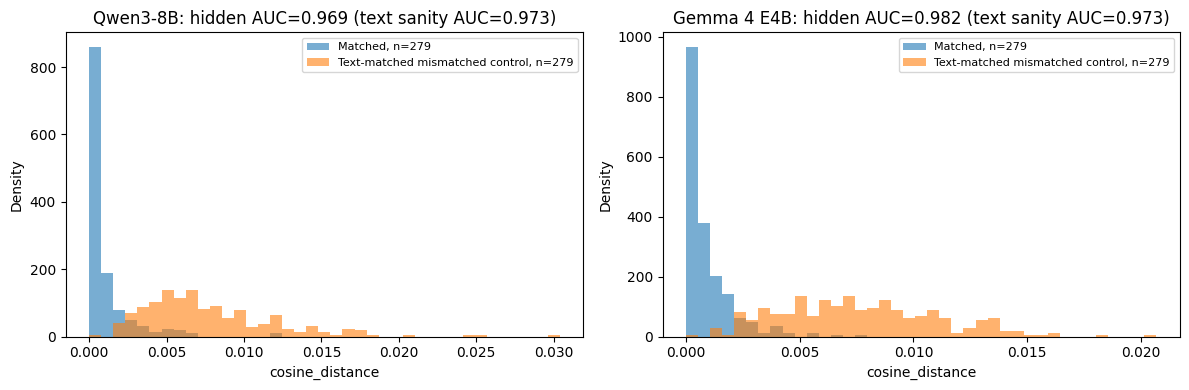

In [22]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
axes = axes[0]
for ax, m in zip(axes, MODELS):
    tm = m["text_matched"]
    bins = np.linspace(
        0, max(tm["matched_hidden"].max(), tm["control_hidden"].max()), 40,
    )
    ax.hist(tm["matched_hidden"], bins=bins, alpha=0.6, density=True,
            label=f"Matched, n={len(tm['matched_hidden'])}")
    ax.hist(tm["control_hidden"], bins=bins, alpha=0.6, density=True,
            label=f"Text-matched mismatched control, n={len(tm['control_hidden'])}")
    ax.set_xlabel(m["top"]["metric"])
    ax.set_ylabel("Density")
    ax.set_title(f"{m['label']}: hidden AUC={tm['auc_hidden_matched']:.3f} (text sanity AUC={tm['auc_text_sanity']:.3f})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**If the sanity-check AUC above is still well above 0.5**, that is itself
a finding worth reporting: it means there simply are *no* unrelated
problem pairs in the dataset that are as textually close as a true
Simple/Hard pair — the matched pairs occupy a region of "textual
closeness" that unrelated problems never reach, even in the best case
found across all ~77.5k candidates. In that situation, the hidden-state
AUC on this section can't be interpreted as "beyond text" evidence
either way, because the control condition (text-matched but unrelated)
barely exists in this dataset. Section 13's residual analysis does not
have this limitation, since it doesn't depend on finding real matched
examples — treat it as the more decisive test between the two.

## 13. Residualized hidden-state distance

Fit `hidden_dist ~ a * edit_dist + b` by least squares over all pairs
(matched + mismatched), then take the residual
`hidden_dist - (a * edit_dist + b)` — the part of hidden-state distance
that a purely-textual predictor does not explain. Re-test matched vs.
mismatched separation using only that residual.

"Residual" means "leftover." We first find the best straight-line relationship between edit distance and hidden-state distance, then subtract that prediction from each pair's actual hidden-state distance. What's left over, the residual, is the part of hidden-state distance that text similarity doesn't already explain. If matched pairs still stand out using only that leftover part, that's real evidence the model is doing something beyond noticing similar wording.


In [23]:
for m in MODELS:
    top = m["top"]
    edit_all = top["edit_dist"]
    hidden_all = top["hidden_dist"]
    labels_all = top["labels"]

    slope, intercept = np.polyfit(edit_all, hidden_all, deg=1)
    predicted = slope * edit_all + intercept
    residual = hidden_all - predicted

    auc_residual = roc_auc_score(labels_all, -residual)
    corr_residual_label = np.corrcoef(residual, labels_all)[0, 1]

    m["top"]["residual"] = residual
    m["top"]["auc_residual"] = auc_residual

    print(f"[{m['label']}] hidden_dist ~ {slope:.4f} * edit_dist + {intercept:.4f}")
    print(f"[{m['label']}] Full (unmatched-text-controlled) AUC: {top['auc']:.4f}")
    print(f"[{m['label']}] Residual-only AUC (edit distance regressed out): {auc_residual:.4f}")
    print(f"[{m['label']}] Correlation(residual, matched-label): {corr_residual_label:.4f}")
    print()

[Qwen3-8B] hidden_dist ~ 0.0260 * edit_dist + -0.0042
[Qwen3-8B] Full (unmatched-text-controlled) AUC: 0.9964
[Qwen3-8B] Residual-only AUC (edit distance regressed out): 0.3437
[Qwen3-8B] Correlation(residual, matched-label): 0.0642

[Gemma 4 E4B] hidden_dist ~ 0.0195 * edit_dist + -0.0021
[Gemma 4 E4B] Full (unmatched-text-controlled) AUC: 0.9993
[Gemma 4 E4B] Residual-only AUC (edit distance regressed out): 0.4544
[Gemma 4 E4B] Correlation(residual, matched-label): 0.0133



In [24]:
residual_summary = pd.DataFrame([
    {
        "model": m["label"],
        "full_auc": m["top"]["auc"],
        "text_only_auc": m["top"]["auc_edit_only"],
        "text_matched_hidden_auc": m["text_matched"]["auc_hidden_matched"],
        "residual_auc": m["top"]["auc_residual"],
    }
    for m in MODELS
])
print("If hidden states add information beyond text: text_matched_hidden_auc and residual_auc")
print("should stay well above 0.5. If they collapse toward 0.5, the original AUC was driven")
print("by textual similarity, not by anything specific to the model's internal representations.")
residual_summary

If hidden states add information beyond text: text_matched_hidden_auc and residual_auc
should stay well above 0.5. If they collapse toward 0.5, the original AUC was driven
by textual similarity, not by anything specific to the model's internal representations.


,model,full_auc,text_only_auc,text_matched_hidden_auc,residual_auc
0,Qwen3-8B,0.996391,0.996835,0.969245,0.343710
1,Gemma 4 E4B,0.999341,0.996835,0.982105,0.454441


## 14. Writing this up in your paper

This section is a checklist for turning the numbers above into a couple of honest paragraphs for your paper. The goal isn't to hide the complication from Section 11; it's to describe it clearly, the way a scientist reports a result that turned out more complicated than it first looked.

### A results paragraph you can adapt

> Across all `N` problems per model, matched Simple/Hard pairs had much
> more similar prompt hidden states than mismatched (unrelated-problem)
> pairs, both for Qwen (`AUC = <fill in Section 7's best_per_model value>`)
> and Gemma (`AUC = <fill in>`). This result held across multiple
> token-pooling strategies (final-token and mean-token; see Section 7).
> However, normalized textual edit distance between the Simple and Hard
> problem text *alone* separated matched from mismatched pairs almost as
> well (text-only AUC `<fill in from Section 9's edit_summary>`),
> indicating that most of this separation is explainable by surface-text
> similarity rather than by anything specific to the models' internal
> representations. A text-matched control analysis (Section 12) and a
> residual analysis that regressed hidden-state distance on edit distance
> (Section 13) were used to test whether any separation survived after
> accounting for text similarity; see `<fill in Section 12/13 conclusion>`.

### What each finding lets you claim (and what it doesn't)

- **You can claim:** "Matched Simple/Hard prompts produce more similar
  hidden states than unrelated problems, at a very high AUC, and this is
  robust to pooling choice." This is a clean, well-supported observational
  finding — cite the Section 7/10 numbers for it.
- **You cannot yet claim** (without more evidence): "The model's hidden
  states capture the *mathematical relationship* between Simple and Hard
  versions of a problem, beyond just noticing similar wording," or
  anything about memorization. Section 11's finding blocks that stronger
  claim until Sections 12-13's residual test comes back clearly positive.
- **Report Section 12/13 honestly either way.** If the residual AUC
  (Section 13) stays well above 0.5, that is itself a genuine, more
  interesting result — say so, and say by how much it dropped from the
  full AUC (that drop is the size of the "purely textual" contribution).
  If it collapses toward 0.5, report that too — a null result that
  narrows down what's going on is still a real contribution, and papers
  that only report the flattering number are the ones that don't hold up
  to scrutiny.
- **Note the dataset limitation from Section 12** if its sanity check
  didn't reach ~0.5: state plainly that no unrelated pair in this 279-
  problem dataset was anywhere near as textually close as a true
  matched pair, so a fully independent text-matched control wasn't
  achievable with this data, and the residual analysis (Section 13) is
  the more decisive evidence.

### Suggested "Limitations" or "Future Work" bullet

> This analysis does not include a test of whether hidden-state distance
> (or its text-residual) predicts *behavioral* failure — i.e., whether the
> model actually gets the Hard version wrong more often when its hidden
> states are more different from the Simple version, after controlling
> for edit distance. That test requires generating and grading model
> answers (not just collecting prompt hidden states) and is a natural next
> step.

*(Update: Section 15 below now implements this test.)*


## 15. Behavioral failure: does hidden-state distance predict C→W transitions?

The residual test in Section 13 asked "do hidden states distinguish
matched from mismatched pairs, beyond text similarity?" and found
essentially no. This section asks a *different* question that survives
that null result: **among matched pairs only, does a bigger
Simple→Hard hidden-state shift predict that the model's behavior
actually flips from correct to wrong?**

For each problem, we generate and grade the model's answer on both the
Simple and Hard versions, then label each matched pair by its
**correctness transition**:

- **C→C**: correct on both Simple and Hard (no failure).
- **C→W**: correct on Simple, wrong on Hard (the perturbation "broke"
  the model).
- **W→C** / **W→W**: wrong on Simple already — less informative for
  this question, reported for completeness only.

We then compare hidden-state distance (both the raw distance from
Section 8 and the edit-distance-*residual* from Section 13) between the
C→C and C→W groups. If distance (especially residual distance) is
systematically larger for C→W than C→C, that's evidence that hidden
states carry signal about upcoming behavioral failure, independent of
the null result in Section 13.

> **Needs a GPU and takes noticeably longer than Section 3**: unlike
> collecting hidden states (one forward pass per problem), this
> *generates* an answer for every Simple/Hard problem (up to
> `MAX_NEW_TOKENS` tokens each, one token at a time). Like Section 3,
> results are cached to disk and collection is skipped automatically if
> the files already exist.

So far we've only asked whether hidden states "know" two problems are the same, and found that's mostly just text-matching. This step asks a different, more useful question: when the model's internal representation shifts a lot from the easy version to the hard version, does the model actually get the hard version wrong more often? We call getting Simple right and Hard wrong a **C→W transition** (Correct→Wrong). If bigger internal shifts line up with more C→W transitions, that's a useful signal, even though Section 13 showed the model doesn't uniquely "recognize" the matched problem beyond its wording.


In [25]:
MATH_PERTURB_DIR = ROOT / "MATH-Perturb"
sys.path.insert(0, str(MATH_PERTURB_DIR))
from evaluate import answer_check  # noqa: E402 (path must be set first)

MAX_NEW_TOKENS = 512
BEHAVIOR_MODE = "non_thinking"
FORCE_RECOLLECT_BEHAVIOR = False

/content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/evaluation/answer_extraction.py:185: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "%")
/content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/evaluation/answer_extraction.py:330: SyntaxWarning: invalid escape sequence '\d'
  pattern = '-?\d*\.?\d+'
/content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/evaluation/eval_script.py:36: SyntaxWarning: invalid escape sequence '\{'
  digit_pred = regex.sub('\{,\}', '', str(pred)) # support numbers like 18{,}234
/content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/evaluation/eval_script.py:37: SyntaxWarning: invalid escape sequence '\{'
  digit_ans = regex.sub('\{,\}', '', str(ans))
/content/Exploring-memorization-in-hidden-states-of-LLMs-via-math-perturbations/MATH-Perturb/evaluation/eval_utils.py:123: Synt

In [ ]:
def behavior_needs_collection(activations_dir: Path) -> bool:
    if FORCE_RECOLLECT_BEHAVIOR:
        return True
    for cond in ("simple", "hard"):
        if not (activations_dir / f"behavior_{cond}_{BEHAVIOR_MODE}.json").exists():
            return True
    return False


def load_behavior(activations_dir: Path):
    behavior = {}
    for cond in ("simple", "hard"):
        path = activations_dir / f"behavior_{cond}_{BEHAVIOR_MODE}.json"
        payload = json.loads(path.read_text(encoding="utf-8"))
        behavior[cond] = payload
    return behavior


def collect_behavior_for_model(m: dict, simple_rows: list[dict], hard_rows: list[dict]):
    activations_dir = m["activations_dir"]

    if not behavior_needs_collection(activations_dir):
        print(f"[{m['label']}] behavior files already present in {activations_dir}, loading them.")
        m["behavior_raw"] = load_behavior(activations_dir)
        return

    print(f"[{m['label']}] loading {m['hf_model_id']} for generation...")
    model, tokenizer, chat_applier = load_causal_lm(m["hf_model_id"])
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    conditions = {"simple": simple_rows, "hard": hard_rows}
    behavior_raw = {}

    for cond, rows in conditions.items():
        problem_ids, correct = [], []
        for row in tqdm(rows, desc=f"[{m['label']}] generate+grade {cond}"):
            prompt_text = format_prompt(chat_applier, row["problem"])
            inputs = tokenizer(
                prompt_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT_TOKENS,
            ).to(DEVICE)
            with torch.inference_mode():
                gen_ids = model.generate(
                    **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, pad_token_id=pad_id,
                )
            new_tokens = gen_ids[0][inputs["input_ids"].shape[1]:]
            generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True)
            try:
                is_correct = bool(answer_check(row["problem"], generated_text, row["answer"], "perturb"))
            except Exception as exc:
                print(f"[{m['label']}] grading error on problem_id={row['problem_id']}: {exc}")
                is_correct = False
            problem_ids.append(row["problem_id"])
            correct.append(is_correct)

        payload = {"problem_ids": problem_ids, "correct": correct}
        behavior_raw[cond] = payload
        save_path = activations_dir / f"behavior_{cond}_{BEHAVIOR_MODE}.json"
        save_path.write_text(json.dumps(payload), encoding="utf-8")
        print(f"[{m['label']}] saved {save_path} ({sum(correct)}/{len(correct)} correct)")

    m["behavior_raw"] = behavior_raw

    del model, tokenizer, chat_applier
    gc.collect()
    torch.cuda.empty_cache()


for m in MODELS:
    collect_behavior_for_model(m, simple_rows, hard_rows)

[Qwen3-8B] loading Qwen/Qwen3-8B for generation...


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

[Qwen3-8B] generate+grade simple:   0%|          | 0/279 [00:00<?, ?it/s]

### Bucket matched pairs by correctness transition, and compare distances

In [ ]:
for m in MODELS:
    behavior_raw = m["behavior_raw"]
    simple_by_pid = dict(zip(behavior_raw["simple"]["problem_ids"], behavior_raw["simple"]["correct"]))
    hard_by_pid = dict(zip(behavior_raw["hard"]["problem_ids"], behavior_raw["hard"]["correct"]))

    simple_correct = np.array([simple_by_pid[pid] for pid in m["problem_ids"]])
    hard_correct = np.array([hard_by_pid[pid] for pid in m["problem_ids"]])

    transitions = np.full(len(simple_correct), "W->W", dtype=object)
    transitions[simple_correct & hard_correct] = "C->C"
    transitions[simple_correct & ~hard_correct] = "C->W"
    transitions[~simple_correct & hard_correct] = "W->C"
    m["transitions"] = transitions

    print(f"[{m['label']}] transition counts:")
    print(pd.Series(transitions).value_counts().to_string())
    print()

In [ ]:
from scipy import stats as scipy_stats

behavior_records = []
for m in MODELS:
    top = m["top"]
    n_matched = len(m["matched_pairs"])
    matched_raw = top["matched_d"]
    matched_residual = top["residual"][:n_matched]
    transitions = m["transitions"]

    df = pd.DataFrame({
        "transition": transitions,
        "raw_distance": matched_raw,
        "residual_distance": matched_residual,
    })
    m["behavior_df"] = df
    print(f"[{m['label']}] distance by transition group:")
    print(df.groupby("transition")[["raw_distance", "residual_distance"]].agg(["mean", "median", "count"]))
    print()

    cc = df.loc[df["transition"] == "C->C", "residual_distance"].to_numpy()
    cw = df.loc[df["transition"] == "C->W", "residual_distance"].to_numpy()
    if len(cc) >= 5 and len(cw) >= 5:
        labels_cw = np.array([0] * len(cc) + [1] * len(cw))
        scores_cw = np.concatenate([cc, cw])
        auc_cw = roc_auc_score(labels_cw, scores_cw)  # positive score = larger distance = predicts C->W
        u_stat, p_value = scipy_stats.mannwhitneyu(cw, cc, alternative="two-sided")
        print(f"[{m['label']}] C->C n={len(cc)}, C->W n={len(cw)}")
        print(f"[{m['label']}] AUC(residual distance predicts C->W over C->C): {auc_cw:.4f}")
        print(f"[{m['label']}] Mann-Whitney U p-value (C->W vs C->C residual distance): {p_value:.4f}")
        behavior_records.append({
            "model": m["label"], "n_CC": len(cc), "n_CW": len(cw),
            "auc_residual_predicts_CW": auc_cw, "mannwhitney_p": p_value,
        })
    else:
        print(
            f"[{m['label']}] Too few C->W examples (n={len(cw)}) for a reliable test "
            "— report the raw counts instead of a statistic."
        )
        behavior_records.append({
            "model": m["label"], "n_CC": len(cc), "n_CW": len(cw),
            "auc_residual_predicts_CW": None, "mannwhitney_p": None,
        })
    print()

behavior_summary = pd.DataFrame(behavior_records)
behavior_summary

In [ ]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
axes = axes[0]
order = ["C->C", "C->W", "W->C", "W->W"]
for ax, m in zip(axes, MODELS):
    df = m["behavior_df"]
    present = [t for t in order if (df["transition"] == t).any()]
    data = [df.loc[df["transition"] == t, "residual_distance"].to_numpy() for t in present]
    ax.boxplot(data, labels=present, showmeans=True)
    ax.set_ylabel("Residual hidden-state distance (edit distance regressed out)")
    ax.set_title(m["label"])
plt.tight_layout()
plt.show()

**How to read this section for your paper:** if `auc_residual_predicts_CW`
is well above 0.5 with a small `mannwhitney_p` (conventionally < 0.05),
that is evidence that hidden-state shifts predict behavioral failure
*even though* they don't uniquely identify the matched problem beyond
text (Section 13). If it's close to 0.5 / p is large, or `n_CW` is too
small to trust, say so plainly — with only 279 problems, `C->W` may be a
small group, and a null or underpowered result here is still worth
reporting honestly rather than omitting.